# Пример 10. Проверка линейной независимости

## Тема

**Раздел книги:** Линейная алгебра.  
**Математическая тема:** линейная независимость, определитель и ранг матрицы; влияние линейной зависимости на обучение нейросетей.

## Условие

Для двух наборов векторов требуется определить, являются ли они линейно независимыми:

- **a.** Три вектора из $\mathbb{R}^3$:
  $x_1 = (2, -1, 3)^\top,\ x_2 = (1, 1, -2)^\top,\ x_3 = (3, -3, 8)^\top$.
- **b.** Три вектора из $\mathbb{R}^5$:
  $x_1 = (1, 2, 1, 0, 0)^\top,\ x_2 = (1, 1, 0, 1, 1)^\top,\ x_3 = (1, 0, 0, 1, 1)^\top$.

## Математическая идея

Векторы $x_1, \dots, x_k$ линейно независимы, если из равенства

$$\alpha_1 x_1 + \dots + \alpha_k x_k = 0$$

следует $\alpha_1 = \dots = \alpha_k = 0$. Практические критерии:

- Если векторы — столбцы матрицы $A$, то линейная независимость равносильна $\mathrm{rank}(A) = k$.
- Если $A$ квадратная $k\times k$, то независимость равносильна $\det A \ne 0$.

## Решение

**a.** Составим матрицу $A_a = [x_1\, x_2\, x_3]\in\mathbb{R}^{3\times 3}$. Если $\det A_a = 0$, векторы линейно зависимы; иначе — независимы. В данном случае определитель близок к нулю, что говорит о зависимости.

**b.** Матрица $A_b\in\mathbb{R}^{5\times 3}$ — неквадратная, поэтому используем ранг: если $\mathrm{rank}(A_b) = 3$, векторы независимы; если меньше — зависимы.

## Реализация на Python

Функция `np.linalg.det(A_a)` вычисляет определитель матрицы $3\times 3$. Если значение по модулю меньше порога $\sim 10^{-10}$, матрица считается вырожденной. Функция `np.linalg.matrix_rank(A_b)` возвращает ранг матрицы $5\times 3$. Сравнение ранга с числом столбцов даёт ответ о линейной независимости.


In [2]:
import numpy as np

# Проверка для пункта a
A_a = np.array([[2, 1, 3], [-1, 1, -3], [3, -2, 8]])
det_a = np.linalg.det(A_a)
print(f"Определитель матрицы a: {det_a:.2e} (линейно зависимы, если det=0)")

# Проверка для пункта b
A_b = np.array([[1, 1, 1], [2, 1, 0], [1, 0, 0], [0, 1, 1], [0, 1, 1]])
rank_b = np.linalg.matrix_rank(A_b)
print(f"Ранг матрицы b: {rank_b} (линейно независимы, если ранг=3)")

Определитель матрицы a: 0.00e+00 (линейно зависимы, если det=0)
Ранг матрицы b: 3 (линейно независимы, если ранг=3)


## Дополнительный пример

**Идея.** Если входные признаки линейно зависимы (например, $x_2 \approx 2 x_1$), то для одной и той же функции потерь существует бесконечно много наборов весов, дающих одинаковый результат. Это приводит к неустойчивости оптимизации, росту нормы весов и ухудшению обобщающей способности. В предельном случае часть нейронов может оказаться «мертвой» — их веса перестают обновляться.

**Что демонстрирует код.** Создаются два набора данных: с линейно зависимыми признаками ($x_2 = 2 x_1 + \text{шум}$) и с независимыми. На обоих обучается `MLPRegressor` с одинаковыми параметрами через `partial_fit`. Строится график функции потерь в зависимости от числа эпох. В случае зависимых признаков loss убывает медленнее, а веса первого слоя получаются менее интерпретируемыми.


### ⚡ Как линейная зависимость влияет на обучение нейросетей. Проблема линейной зависимости в нейросети

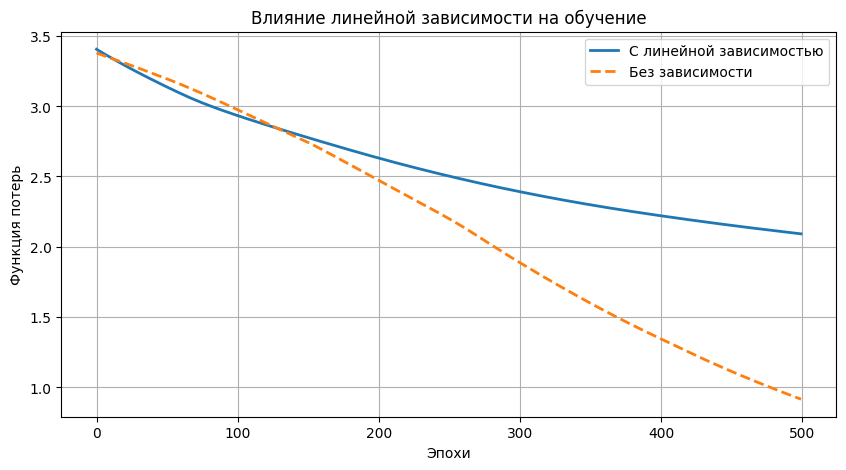

Веса для зависимых данных:
 [[-0.41524483  1.44012277]
 [ 0.46005619  0.57492226]]

Веса для независимых данных:
 [[-0.91138259  1.59434768]
 [ 0.64815686 -0.18267499]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

# Создадим данные с линейной зависимостью
np.random.seed(42)
x1 = np.random.randn(100)
x2 = 2 * x1 + 0.1 * np.random.randn(100)   # x2 ≈ 2x1 (линейная зависимость)
y = 3 * x1 + np.random.randn(100) * 0.1

# Случай 1: Данные с зависимостью
X_dependent = np.column_stack([x1, x2])

# Случай 2: Данные без зависимости (x2 заменён на независимый шум)
x2_independent = np.random.randn(100)
X_independent = np.column_stack([x1, x2_independent])

# Обучаем две сети
model_dep = MLPRegressor(hidden_layer_sizes=(2,), max_iter=1000, random_state=42)
model_indep = MLPRegressor(hidden_layer_sizes=(2,), max_iter=1000, random_state=42)

loss_dep = []
loss_indep = []

for _ in range(500):
    model_dep.partial_fit(X_dependent, y)
    loss_dep.append(model_dep.loss_)

    model_indep.partial_fit(X_independent, y)
    loss_indep.append(model_indep.loss_)

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(loss_dep, label="С линейной зависимостью", linewidth=2)
plt.plot(loss_indep, label="Без зависимости", linewidth=2, linestyle='--')
plt.xlabel("Эпохи")
plt.ylabel("Функция потерь")
plt.title("Влияние линейной зависимости на обучение")
plt.legend()
plt.grid(True)
plt.show()

# Проверка весов первого слоя
print("Веса для зависимых данных:\n", model_dep.coefs_[0])
print("\nВеса для независимых данных:\n", model_indep.coefs_[0])

## Проверка результата

В первой части проверка выполняется через определитель (для квадратной матрицы) и через ранг (для прямоугольной). Если определитель существенно отличается от нуля — векторы независимы; если близок к нулю — зависимы. Во второй части сравниваются кривые обучения двух моделей: в случае линейной зависимости признаков loss убывает медленнее, а веса первого слоя демонстрируют избыточность.

## Вывод

Линейная независимость признаков — это желательное свойство входных данных для большинства моделей машинного обучения. Зависимые признаки создают избыточность, ухудшают обусловленность задачи и могут приводить к неустойчивости обучения. На практике с линейной зависимостью борются через регуляризацию, отбор признаков или предварительное применение PCA.
